# Lecture 20 (Generators, iterators, and context managers)

## Exercise 20.1 (huge ranges)

Explain the difference between `sum(range(1_000_000_000))` and `sum(list(range(1_000_000_000)))`.

In [ ]:
# sum iterates over all values in range, space efficient
print(sum(range(100_000_000)))

# create huge explicit list of integers first before summing, space inefficient
print(sum(list(range(100_000_000))))


4999999950000000
4999999950000000
<class 'range'>


## Exercise 20.2 (subsequence)

Create a function `is_subsequence(X, Y)` that takes two iterable sequences, and returns if `X` is a subsequence of `Y`, i.e., if `X` can be obtained by deleting zero or more characters from `Y`. Your solution should only assume that the sequences are iterable, i.e., you can call `iter` on them but you cannot index into the sequences.

    > is_subsequence([1,3,5], [1,2,4,5])
    False
    > is_subsequence([3,10,8,5], [2,8,3,10,5,8,5,11])
    True
    > from itertools import count, islice
    > is_subsequence(islice(count(6, 12), 100), islice(count(0, 2), 1000))
    True
    > is_subsequence(islice(count(6, 13), 100), islice(count(0, 2), 1000))
    False

In [ ]:
def is_subsequence(X, Y):
    '''Solution using next and StopIteration exception.'''

    ys = iter(Y)
    for x in X:
        try:
            while x != next(ys):
                pass
        except StopIteration:
            return False
    return True


def is_subsequence(X, Y):
    '''Solution using iterator and for-break-else.'''

    ys = iter(Y)
    for x in X:
        for y in ys:
            if x == y:
                break
        else:
            return False
    return True


print(f'{is_subsequence([1, 3, 5], [1, 2, 4, 5]) = }')
print(f'{is_subsequence([3, 10, 8, 5], [2, 8, 3, 10, 5, 8, 5, 11]) = }')

from itertools import count, islice

print(f'{is_subsequence(islice(count(6, 12), 100), islice(count(0, 2), 1000)) = }')
print(f'{is_subsequence(islice(count(6, 13), 100), islice(count(0, 2), 1000)) = }')

is_subsequence([1, 3, 5], [1, 2, 4, 5]) = False
is_subsequence([3, 10, 8, 5], [2, 8, 3, 10, 5, 8, 5, 11]) = True
is_subsequence(islice(count(6, 12), 100), islice(count(0, 2), 1000)) = True
is_subsequence(islice(count(6, 13), 100), islice(count(0, 2), 1000)) = False


## Exercise 20.3 (Fibonacci numbers - generator and iterator)

1.  **Fibonacci generator**: Make a generator `fib(n)` to generate the first `n` [Fibonacci numbers](https://mathworld.wolfram.com/FibonacciNumber.html). Your solution should use the `yield` keyword.

        > print(list(fib(10)))
        [1, 1, 2, 3, 5, 8, 13, 21, 34, 55]
        > print(sum(fib(100)))
        927372692193078999175

2.  **Fibonacci iterator**: Create an iterable `class Fibonacci` with methods `__init__` and `__iter__` and an iterator `class FibonacciIterator` with methods `__init__` and `__next__`. The object creation `Fibonacci(n)` should create an iterable object for the first `n` Fibonacci numbers, and the `__iter__` method should return an instance of `FibonacciIterator`. In the `class FibonacciIterator` implement the method `__next__`, that either returns the next Fibonacci number or raises a `StopIteration` exception.

        > f = Fibonacci(5)
        > type(f)
        <class '__main__.Fibonacci'>
        > it = iter(f)
        > type(it)
        <class '__main__.FibonacciIterator'>
        > next(it)
        1
        > next(it)
        1
        > next(it)
        2
        > next(it)
        3
        > next(it)
        5
        > next(it)
        StopIteration
        > for _ in range(3):
              for x in f:
                  print(x, end=' ')
        1 1 2 3 5 1 1 2 3 5 1 1 2 3 5

In [ ]:
def fib(n):
    fib0 = 0
    fib1 = 1
    for _ in range(n):
        yield fib1
        fib0, fib1 = fib1, fib0 + fib1

print(list(fib(10)))
print(sum(fib(100)))

<generator object fib at 0x000001A51FD63760>
[1, 1, 2, 3, 5, 8, 13, 21, 34, 55]
927372692193078999175


In [2]:
class FibonacciIterator:
    def __init__(self, n):
        self.n = n
        self.fib0 = 0
        self.fib1 = 1

    def __next__(self):
        if self.n == 0:
            raise StopIteration
        else:
            if self.n != None:
                self.n -= 1
            self.fib0, self.fib1 = self.fib1, self.fib0 + self.fib1
            return self.fib0

    def __iter__(self):
        return self


class Fibonacci:
    def __init__(self, n=None):
        self.n = n

    def __iter__(self):
        return FibonacciIterator(self.n)


if __name__ == '__main__':
    f = Fibonacci(10)
    for x in f:
        print(x, end=' ')
    for x in f:
        print(x, end=' ')


1 1 2 3 5 8 13 21 34 55 1 1 2 3 5 8 13 21 34 55 

## Exercise 20.4 (subsets generator)

Make a generator version of the `subsets` function (see Exercise 8.2) using the `yield` keyword.

In [ ]:
'''
Generator 'subsets' that given a list L, returns a list of all subsets of L

Example: subsets([1, 2]) -> [[], [1], [2], [1, 2]]
'''


def subsets_generator(S):
    if len(S) == 0:
        yield []
    else:
        for s in subsets_generator(S[1:]):
            yield s
            yield S[:1] + s


print(subsets_generator([1, 2, 3]))
print(list(subsets_generator([1, 2, 3])))

<generator object subsets_generator at 0x00000129FF6A5FC0>
[[], [1], [2], [1, 2], [3], [1, 3], [2, 3], [1, 2, 3]]


## Exercise 20.5 (subset sum generator)

Write a generator function `subset_sum(x, L)` that reports all subsets of `L` with sum `x` (see also Exercise 13.4). Your solution should use the generator function from Exercise 20.4.

In [3]:
def subsets(L):
    if len(L) == 0:
        yield []
    else:
        for s in subsets(L[1:]):
            yield s
            yield [L[0]] + s


def subset_sum(x, L):
   for s in subsets(L):
       if sum(s) == x:
           yield s


print(list(subset_sum(12, [2, 3, 8, 11, -1])))

print(list(subset_sum(6, [2, 3, 8, 11, -1])))

[[2, 3, 8, -1], [2, 11, -1]]
[]


## Exercise 20.6 (permutations generator)

Make a generator function `permutations(L)` that given a list `L` generates all permutations of `L`. The method should use the `yield` keyword. The order of the returned lists can be arbitrary.

_Example_. `permutations([1, 2])` should return `[[1, 2], [2, 1]]`.

_Note_. An implementation of the permutations generator also exists in the standard library `itertools` (but in this
exercise you should of course write the function from scratch). An example usage is:


    > from itertools import permutations
    > permutations([1, 2, 3])
    <tertools.permutations object at 0x03C4CA80&gt;
    > list(permutations([1, 2, 3]))
    [(1, 2, 3), (1, 3, 2), (2, 1, 3), (2, 3, 1), (3, 1, 2), (3, 2, 1)]

In [12]:
def permutations1(L):
    if len(L) == 0:
        yield L[:]  # Keep the same type as L
    else:
        for p in permutations1(L[1:]):
            for i in range(len(L)):
                yield p[:i] + L[:1] + p[i:]

def permutations2(S):
    yield from ((s, *p) for i, s in enumerate(S) for p in permutations2(S[:i] + S[i + 1:])) if S else [()]

def permutations3(S):
    yield from (S[i:i + 1] + p for i in range(len(S)) for p in permutations3(S[:i] + S[i + 1:])) if S else [S[:0]]

def permutations4(S):
    yield from (p[:i] + S[:1] + p[i:] for p in permutations4(S[1:]) for i in range(len(S))) if S else [S[:0]]

def permutations7(S, prefix=None):
    if not prefix:
        prefix = S[:0]

    if not S:
        yield prefix
    else:
        for j in range(len(S)):
            yield from permutations7(S[:j] + S[j+1:], prefix + S[j:j+1])


#################
# non-generators

def permutations5(S):
    solution = [S[:0]]
    for j in range(len(S)):
        solution = [p[:i] + S[j:j+1] + p[i:] for p in solution for i in range(len(p) + 1)]
    return solution

def permutations6(S):
    if S:
        perms = permutations6(S[1:])
        return [p[:i] + S[:1] + p[i:] for p in perms for i in range(len(p) + 1)]
    return [S[:0]]

from time import time
import itertools

functions = [itertools.permutations]
functions.extend(f for fn, f in sorted(globals().items()) if fn[:11]=='permutation')

V = 'X', (42,), [42]
X = range(4, 10)
T = {f.__name__: {type(v):[] for v in V} for f in functions}
for n in X:
    for value in V:
        seq = value * n
        for permutation in functions:
            start = time()
            x = len(list(permutation(seq)))
            end = time()
            duration = end - start
            name = permutation.__name__
            print(name, type(value), duration, x)
            T[name][type(value)].append(duration)

import matplotlib.pyplot as plt

for f in functions:
    for value in V:
        name = f.__name__
        plt.plot(X, T[name][type(value)], label=name + ', ' + str(type(value)))
plt.legend(loc='upper left')
plt.show()

permutations <class 'str'> 1.2159347534179688e-05 24
permutations1 <class 'str'> 3.0279159545898438e-05 24
permutations2 <class 'str'> 7.43865966796875e-05 24
permutations3 <class 'str'> 5.841255187988281e-05 24
permutations4 <class 'str'> 2.1219253540039062e-05 24
permutations5 <class 'str'> 1.7642974853515625e-05 24
permutations6 <class 'str'> 1.4781951904296875e-05 24
permutations7 <class 'str'> 3.600120544433594e-05 24
permutations <class 'tuple'> 6.4373016357421875e-06 24
permutations1 <class 'tuple'> 0.0001747608184814453 24
permutations2 <class 'tuple'> 0.00016546249389648438 24
permutations3 <class 'tuple'> 6.29425048828125e-05 24
permutations4 <class 'tuple'> 2.7179718017578125e-05 24
permutations5 <class 'tuple'> 2.1696090698242188e-05 24
permutations6 <class 'tuple'> 1.4066696166992188e-05 24
permutations7 <class 'tuple'> 3.933906555175781e-05 24
permutations <class 'list'> 5.0067901611328125e-06 24
permutations1 <class 'list'> 2.288818359375e-05 24
permutations2 <class 'lis

KeyboardInterrupt: 

## Exercise 20.7* (linked list)

![Linked list](images/linked_list.png)

Lists are fundamental to Python, but a shortcoming of Python's builtin lists is that `L.extend(L2)` takes time proportional to the number of elements added to `L` from `L2`. In this exercise you should implement the alternative _linked lists_, more precisely _cyclic singly linked lists_.

Implement two classes `Node` and `LinkedList`.

`Node` objects should have two data attributes `element` and `next`. The class `Node` should have one method:

* `n = Node(element)` should create a new node with element `element` and `next` pointing to the node itself (implement `__init__`).

`LinkedList` objects should have a single data attribute `last` pointing to the last node on the cyclic linked list.  If a list is empty, `last` should be `None`.

The class `LinkedList` should support the following methods (all only changing a constant number of data attributes):

* `L = LinkedList()` should construct an empty list (implement `__init__`).

* `L.empty()` returns if the list `L` is empty, i.e. contains no nodes.

* `L.push(e)` adds a new node at the _front_ of the list containing `e`.

* `L.pop()` removes the first node from the _front_ of the list and returns the element the node contained.

* `L.__iter__()` should be a _generator_ to iterate over all the elements in the list.

* `L.extend(L2)` inserts the linked list `L2` at the end of the linked list `L`. Sets `L2.last = None`.

_Example_. The figure shows the linked list `L` after executing the below first three `push` operations.


    > L = LinkedList()
    > L.push(1)
    > L.push(2)
    > L.push(3)
    > list(L)  # constructs a Python list by iterating over the elements of L
    [3, 2, 1]
    > L.pop()
    3
    > L2 = LinkedList()
    > L2.push(5)
    > L2.push(6)
    > L2.push(7)
    > L.extend(L2)
    > L2.empty()
    True
    > list(L2)
    []
    > list(L)
    [7, 6, 5, 2, 1]


_Note_. Linked lists are standard in many languages, e.g. in C++ as [`std::list`](https://en.cppreference.com/w/cpp/container/list) and in Java [`java.util.LinkedList`](https://docs.oracle.com/javase/10/docs/api/java/util/LinkedList.html) - just not in Python. (Doubly) linked lists benefit from being efficient to concatenate and to support the efficient deletion of an arbitrary element in the middle of the list, but suffer from having no efficient index lookup.

In [ ]:
class LinkedList:
    class Node:
        def __init__(self, e):
            self.element = e
            self.next = self

    def __init__(self, values=()):
        self.last = None
        for e in values:
            self.push(e)

    def empty(self):
        return self.last == None

    def extend(self, other):
        if other.last != None:
            if self.last == None:
                self.last = other.last
            else:
                self.last.next, other.last.next, self.last = other.last.next, self.last.next, other.last
            other.last = None

    def pop(self):
        e = self.last.next.element
        if self.last.next == self.last:
            self.last = None
        else:
            self.last.next = self.last.next.next
        return e

    def push(self, e):
        node = LinkedList.Node(e)
        if self.last == None:
            self.last = node
        else:
            node.next = self.last.next
            self.last.next = node

    def __iter__(self):
        if self.last:
            it = self.last.next
            yield it.element
            while it.next != self.last.next:
                it = it.next
                yield it.element

    def __len__(self):
        return sum(1 for e in self)

    def __repr__(self):
        return self.__class__.__name__ + '(' + ', '.join(repr(e) for e in self) + ')'

## Exercise 20.8 - handin 10 (random walk)

![Random walk](images/random_walk.png)

1.  Create a generator function `random_walk` that uses `yield` to generate an _infinite sequence_ of points on a 2D integer grid. The first point should be (0,0), and each subsequent point a random of the four neighbors of the previous point. E.g. the following sequence:

        (0, 0) (1, 0) (1, 1) (2, 1) (2, 0) (1, 0) (0, 0) (0, 1) (-1, 1) (-2, 1) (-1, 1) (-2, 1) (-3, 1) (-2, 1) (-3, 1)...


2.  Use the `imshow` or `hist2d` and `colorbar` functions from the `pyplot` module to visualize the frequency the different cells are visited in a random walk of length 1000.

_Hint_. `import matplotlib.pyplot as plt; plt.imshow([[1,2,4],[0,3,-1]]); plt.colorbar(); plt.show()`

_Hint_. `imshow` takes an optional argument `extent` to adjust the _x_-axis and _y_-axis.

_Hint_. Use `itertools.islice` to get a finite prefix of an infinite iterator. Depending of your approach, `collections.Counter` might become handy.

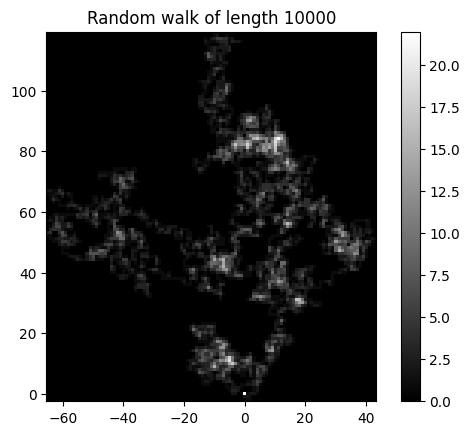

In [10]:
# To allow interaction in Jupyter notebook, uncomment below line
#%matplotlib notebook

from random import randint
import matplotlib.pyplot as plt
from itertools import islice
from collections import Counter

DX = [1, -1, 0, 0]
DY = [0, 0, 1, -1]


def random_walk():
    x, y = 0, 0
    while True:
        yield x, y
        direction = randint(0, 3)
        x += DX[direction]
        y += DY[direction]


N = 10000
visits = Counter(islice(random_walk(), N))
visits[(0, 0)] = max(visits.values())  # emphasize the starting point

X, Y = zip(*visits)

x_min, x_max = min(X), max(X)
y_min, y_max = min(Y), max(Y)

image = [[visits.get((x, y), 0)
          for x in range(x_min, x_max + 1)]
          for y in range(y_min, y_max + 1)]

plt.imshow(
    image,
    extent=(x_min - 0.5, x_max + 0.5, y_min - 0.5, y_max + 0.5),
    cmap='gray',
    origin = 'lower'  # show first row of pixels at the bottom
)
plt.title(f'Random walk of length {N}')
plt.colorbar()
plt.savefig('random_walk.png', dpi=100)
plt.show()

In [4]:
import numpy as np
import random 

x,y = (0,0)
dir = [(1,0), (-1,0), (0,1), (0,-1)]

dx, dy = random.choice(dir)
x+=dx; y+=dy

print((x,y))


(-1, 0)
